In [3]:

# after theory we got to know that what is SMOTE and why we are using it..

# so we first take the help of sklearn library for creating fake imbalance datasets

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, 
    n_redundant=0, 
    n_features=2, 
    n_clusters_per_class=1, 
    weights=[0.90], 
    random_state=12
)

Code Breakdown (Ek-Ek Parameter Ka Matlab)
make_classification(...): Ye sklearn ka ek helper tool hai jo practice ke liye fake/synthetic tabular dataset generate karke deta hai.

n_samples=1000: Iska matlab Sir ne python se bola ki total 1000 rows (data points) generate karo.

n_features=2: Iska matlab table me 2 independent columns (Input Features X 
1
​
 ,X 
2
​
 ) honge. Sir ne 2 features isliye rakhe taaki 2D graph par plotting karke easily visual samjha sakein.

n_redundant=0: Iska matlab koi faltu ya repetitive column mat banana jo pehle wale columns ki duplicate copy ho.

n_clusters_per_class=1: Graph par har class (0 aur 1) ka data ek hi jagah par clustered (jhund me) group hoga, bikhra hua nahi.

weights=[0.90]: YEHI HAI SABSE IMPORTANT PARAMETER!

Isne dataset ko Imbalanced banaya.

[0.90] ka matlab hai ki 90% data Class 0 ka hoga (900 rows) aur baaki bacha 10% data Class 1 ka hoga (100 rows).

random_state=12: Ye code jab bhi run ho, exact wahi same numbers generate hon jo Sir ke screen par dikh rahe hain (reproducibility ke liye).

Isse Overall Kya Hua Aur Imbalanced Data Kaise Bana?
Sir ne bina kisi external CSV file ko download kiye, Jupyter Notebook ke andar hi ek dataset create kar liya.

Output me Sir ko 2 variables mile:

X: Isme 1000 rows aur 2 columns hain (Input parameters).

y: Isme 1000 values hain (0 ya 1).

Imbalanced kaise bana? weights=[0.90] dene ki wajah se:

Class 0 (Majority): 900 rows.

Class 1 (Minority): 100 rows.

Dono classes ka ratio 9:1 ho gaya, jo ek perfect Imbalanced Dataset hai. Ab Sir is par SMOTE apply karke 100 wali class ko 900 tak synthetic points se balance karke dikhayenge.

In [4]:
import pandas as pd

df1 = pd.DataFrame(X, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])

final_df = pd.concat([df1, df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [5]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

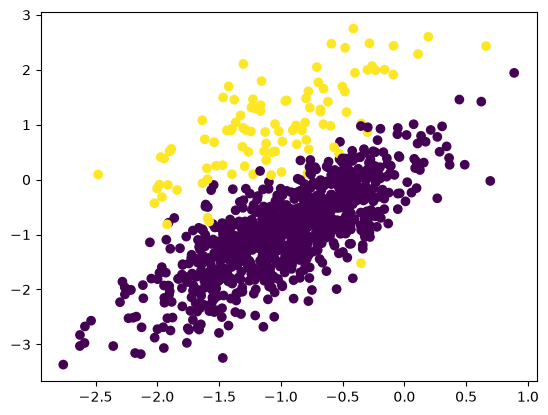

In [6]:
import matplotlib.pyplot as plt 

plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [8]:
# now purple are majority and yellow one are minority so now we apply SMOTE and using imblearn

from imblearn.over_sampling import SMOTE


oversample = SMOTE()
X, y = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])


In [9]:
X.shape

(1800, 2)

In [12]:
y.shape

len(y[y==0])

len(y[y==1])

900

In [13]:
df1 = pd.DataFrame(X, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])

oversample_df = pd.concat([df1, df2], axis=1)

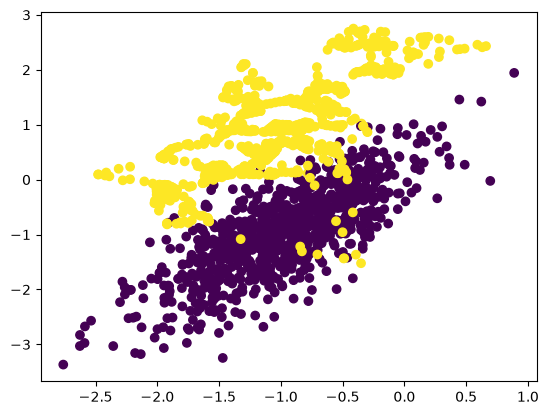

In [14]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])